In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "src").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("找不到项目根目录（包含 src 的目录）")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /home/joyce/projects/cross-asset-quant-lab/cryptoAlpha


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from src.data.registry import DataRegistry
from src.data.loaders.coinglass_loader import CoinglassLoader
from src.data.loaders.coingecko_loader import CoingeckoLoader
from src.data.loaders.cryptoracle_loader import CryptoracleLoader
from src.data.panel_builder import build_base_panel, filter_panel_by_time, panel_info

from src.factors.factor_builder import FactorBuilder
from src.evaluation.factor_evaluator import FactorEvaluator
from src.backtest.engine import FactorBacktestEngine
from src.backtest.metrics import summarize_backtest

In [3]:
START_TIME = "2025-01-01"
END_TIME = "2026-03-11"

SYMBOLS = [
    "BTCUSDT",
    "ETHUSDT",
    "BNBUSDT",
    "XRPUSDT",
    "SOLUSDT",
    "DOGEUSDT",
    "ADAUSDT",
    "TRXUSDT",
    "LINKUSDT",
    "LTCUSDT",
    "AVAXUSDT",
    "MATICUSDT",
    "DOTUSDT",
    "BCHUSDT",
    "XLMUSDT",
    "ATOMUSDT",
    "NEARUSDT",
    "ETCUSDT",
    "FILUSDT",
    "APTUSDT",
]

CRYPTORACLE_METRICS = [
    "active_community_count",
    "mention_count",
    "positive_sentiment_ratio",
    "negative_sentiment_ratio",
]

In [4]:
registry = DataRegistry(str(PROJECT_ROOT / "configs" / "paths.yaml"))

cg_loader = CoinglassLoader(registry)
gecko_loader = CoingeckoLoader(registry)
oracle_loader = CryptoracleLoader(registry)

In [5]:
price_df = cg_loader.load_many_symbols(
    dataset="FUTURES_PRICE_HISTORY",
    symbols=SYMBOLS,
    freq="1h",
    exchange="Binance",
    start_time=START_TIME,
    end_time=END_TIME,
)

funding_df = cg_loader.load_many_symbols(
    dataset="FUTURES_FUNDING_RATE_HISTORY",
    symbols=SYMBOLS,
    freq="1h",
    exchange="Binance",
    start_time=START_TIME,
    end_time=END_TIME,
)

oi_df = cg_loader.load_many_symbols(
    dataset="FUTURES_OPEN_INTEREST",
    symbols=SYMBOLS,
    freq="1h",
    exchange="Binance",
    start_time=START_TIME,
    end_time=END_TIME,
)

taker_df = cg_loader.load_many_symbols(
    dataset="FUTURES_TAKER_BUY_SELL_VOLUME",
    symbols=SYMBOLS,
    freq="1h",
    exchange="Binance",
    start_time=START_TIME,
    end_time=END_TIME,
)

ls_df = cg_loader.load_many_symbols(
    dataset="FUTURES_GLOBAL_LS_ACCOUNT_RATIO",
    symbols=SYMBOLS,
    freq="1h",
    exchange="Binance",
    start_time=START_TIME,
    end_time=END_TIME,
)

print("price_df:", price_df.shape)
print("funding_df:", funding_df.shape)
print("oi_df:", oi_df.shape)
print("taker_df:", taker_df.shape)
print("ls_df:", ls_df.shape)

price_df: (197923, 7)
funding_df: (197923, 6)
oi_df: (194807, 6)
taker_df: (197923, 4)
ls_df: (194807, 5)


In [6]:
gecko_df = gecko_loader.load_many_market_chart_hourly(
    symbols=SYMBOLS,
    start_time=START_TIME,
    end_time=END_TIME,
)

print("gecko_df:", gecko_df.shape)
gecko_df.head()

gecko_df: (197793, 5)


,datetime,symbol,price,market_cap,total_volume
0,2025-01-01,ADAUSDT,0.843667,3.023692e+10,7.240589e+08
1,2025-01-01,APTUSDT,8.696911,4.852333e+09,2.022174e+08
2,2025-01-01,ATOMUSDT,6.180840,2.414793e+09,1.348733e+08
3,2025-01-01,AVAXUSDT,35.646533,1.462620e+10,3.355526e+08
4,2025-01-01,BCHUSDT,433.756245,8.596468e+09,2.057742e+08


In [7]:
oracle_dict = oracle_loader.load_many_symbols_many_metrics(
    symbols=SYMBOLS,
    metrics=CRYPTORACLE_METRICS,
    freq="1h",
    start_time=START_TIME,
    end_time=END_TIME,
)

for k, v in oracle_dict.items():
    print(k, v.shape)

active_community_count (164320, 3)
mention_count (164280, 3)
positive_sentiment_ratio (164336, 3)
negative_sentiment_ratio (164354, 3)


In [5]:
panel_df = build_base_panel(
    price_df=price_df,
    funding_df=funding_df,
    oi_df=oi_df,
    taker_df=taker_df,
    ls_df=ls_df,
    gecko_df=gecko_df,
    oracle_df_dict=oracle_dict,
)

panel_df = filter_panel_by_time(
    panel_df,
    start_time=START_TIME,
    end_time=END_TIME,
)

print("panel_df:", panel_df.shape)
display(panel_df.head())
display(panel_info(panel_df))

NameError: name 'price_df' is not defined

In [9]:
required_cols = [
    "datetime",
    "symbol",
    "close",
    "volume_usd",
    "funding_close",
    "oi_close",
    "taker_buy_volume_usd",
    "taker_sell_volume_usd",
    "global_account_long_short_ratio",
    "market_cap",
    "total_volume",
    "active_community_count",
]

existing = [c for c in required_cols if c in panel_df.columns]
missing = [c for c in required_cols if c not in panel_df.columns]

print("existing:", existing)
print("missing:", missing)

existing: ['datetime', 'symbol', 'close', 'volume_usd', 'funding_close', 'oi_close', 'taker_buy_volume_usd', 'taker_sell_volume_usd', 'global_account_long_short_ratio', 'market_cap', 'total_volume', 'active_community_count']
missing: []


In [4]:
cache_dir = PROJECT_ROOT / "data" / "cache"
cache_dir.mkdir(parents=True, exist_ok=True)

panel_fp = cache_dir / "panel_top20_1h_2025_20260311.parquet"
panel_df.to_parquet(panel_fp, index=False)

print(panel_fp)

NameError: name 'panel_df' is not defined

In [ ]:
cache_dir = PROJECT_ROOT / "data" / "cache"
cache_dir.mkdir(parents=True, exist_ok=True)

panel_fp = cache_dir / "panel_top20_1h_2025_20260311.parquet"
panel_df = pd.read_parquet(panel_fp)
builder = FactorBuilder()

factor_names = [
    "mom_6h",
    "mom_24h",
    "ema_ratio_24",
    "realized_vol_24",
    "volume_ratio_24",
    "funding_z_24",
    "oi_change_24h",
    "taker_imbalance",
    "long_short_ratio_z_24",
    "active_community_count_z_24",
]

factor_df = builder.compute_many(panel_df, factor_names)

print("factor_df:", factor_df.shape)
display(factor_df[factor_df["datetime"]>"2025-02-01"].head())

ValueError: Unknown factor: mom_6h

In [14]:
feature_dir = PROJECT_ROOT / "data" / "features"
feature_dir.mkdir(parents=True, exist_ok=True)

factor_fp = feature_dir / "factor_top20_1h_2025_20260311.parquet"
factor_df.to_parquet(factor_fp, index=False)

print(factor_fp)

/home/joyce/projects/cross-asset-quant-lab/cryptoAlpha/data/features/factor_top20_1h_2025_20260311.parquet


In [15]:
evaluator = FactorEvaluator(price_col="close")

summary_df = evaluator.evaluate_many_factors(
    panel_df=panel_df,
    factor_df=factor_df,
    factor_names=factor_names,
    horizon=1,
    group_num=5,
)

summary_df

/home/joyce/projects/cross-asset-quant-lab/cryptoAlpha/src/evaluation/factor_evaluator.py:66: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic = merged_df.groupby("datetime").apply(
/home/joyce/projects/cross-asset-quant-lab/cryptoAlpha/src/evaluation/factor_evaluator.py:69: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank_ic = merged_df.groupby("datetime").apply(
/home/joyce/projects/cross-asset-quant-lab/cryptoAl

,factor_name,horizon,n_obs,coverage,ic_mean,ic_std,ic_ir,rank_ic_mean,rank_ic_std,rank_ic_ir,factor_autocorr_mean,ls_mean_ret,ls_std_ret,ls_sharpe_naive
0,rev_6h,1,197771,1.0,0.019372,0.363613,0.053277,0.023275,0.318692,0.073033,0.798433,-0.000016,0.005278,-0.003071
1,funding_z_24,1,197676,1.0,0.007352,0.258673,0.028422,0.005847,0.253693,0.023049,0.887319,0.000086,0.003524,0.024332
2,ls_ratio_z_24,1,194598,1.0,0.000454,0.258926,0.001752,0.003292,0.257108,0.012805,0.863060,-0.000006,0.003607,-0.001609
3,taker_imbalance,1,197885,1.0,0.002770,0.253706,0.010917,0.001641,0.249331,0.006581,0.079018,0.000068,0.003512,0.019500
4,volume_ratio_24,1,197676,1.0,-0.001747,0.302469,-0.005776,-0.002304,0.262601,-0.008773,0.412529,0.000094,0.004166,0.022476
5,active_community_count_z_24,1,164144,1.0,-0.006737,0.267786,-0.025158,-0.005395,0.262918,-0.020520,0.375156,0.000007,0.004034,0.001806
6,oi_chg_24h,1,197429,1.0,-0.012459,0.322098,-0.038681,-0.015050,0.271259,-0.055482,0.962088,-0.000024,0.004564,-0.005309
7,mom_24h,1,197429,1.0,-0.024709,0.368002,-0.067143,-0.030700,0.321104,-0.095608,0.944892,-0.000103,0.005223,-0.019638
8,close_to_ma24,1,197676,1.0,-0.025987,0.370894,-0.070065,-0.031650,0.323686,-0.097780,0.922884,-0.000063,0.005184,-0.012060


In [16]:
factor_name = "mom_24h"

result = evaluator.evaluate_one_factor(
    panel_df=panel_df,
    factor_df=factor_df,
    factor_name=factor_name,
    horizon=1,
    group_num=5,
)

result["summary"]

/home/joyce/projects/cross-asset-quant-lab/cryptoAlpha/src/evaluation/factor_evaluator.py:66: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic = merged_df.groupby("datetime").apply(
/home/joyce/projects/cross-asset-quant-lab/cryptoAlpha/src/evaluation/factor_evaluator.py:69: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank_ic = merged_df.groupby("datetime").apply(
/home/joyce/projects/cross-asset-quant-lab/cryptoAl

{'factor_name': 'mom_24h',
 'horizon': 1,
 'n_obs': 197429,
 'coverage': 1.0,
 'ic_mean': -0.024708869064494755,
 'ic_std': 0.3680022517324379,
 'ic_ir': -0.06714325509723404,
 'rank_ic_mean': -0.030699976018856392,
 'rank_ic_std': 0.3211038625129025,
 'rank_ic_ir': -0.09560761984769713,
 'factor_autocorr_mean': 0.9448923332145581,
 'ls_mean_ret': -0.00010257016829941228,
 'ls_std_ret': 0.005223101270662045,
 'ls_sharpe_naive': -0.01963779045524296}

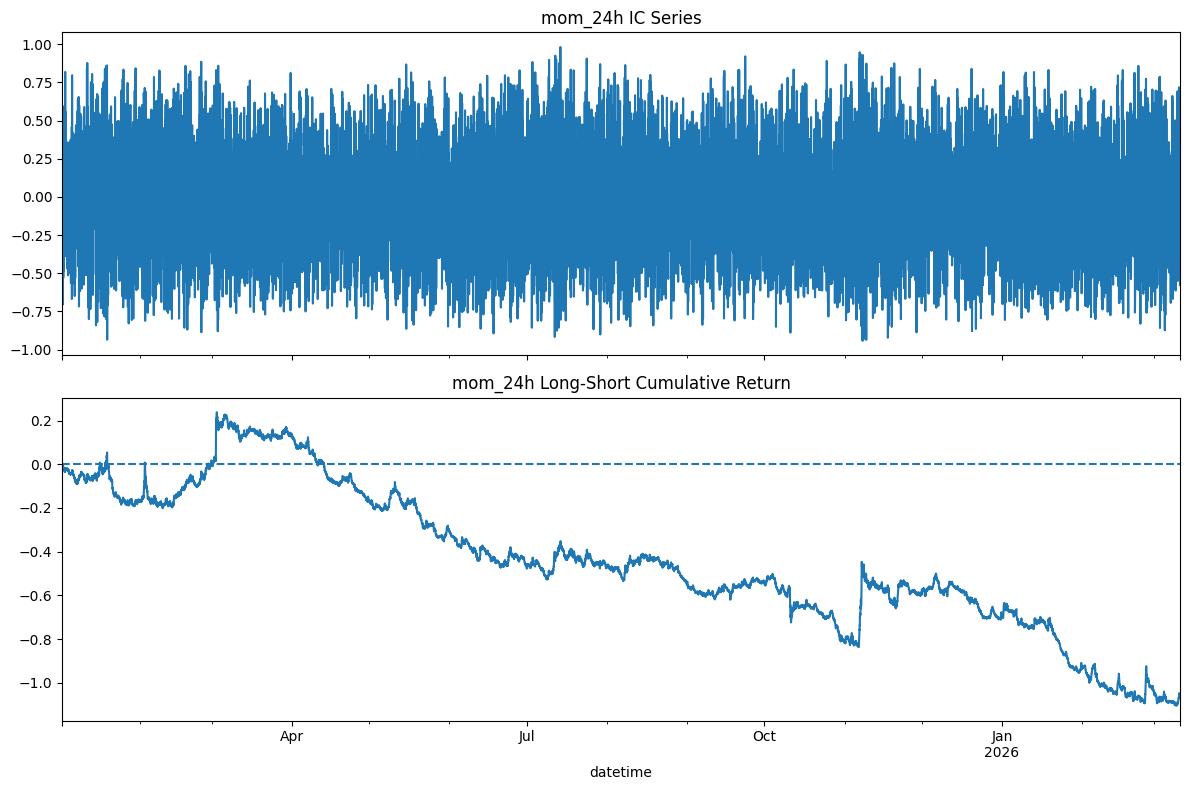

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

result["ic_series"].plot(ax=axes[0], title=f"{factor_name} IC Series")
axes[0].axhline(0, linestyle="--")

result["long_short_cumret"].plot(ax=axes[1], title=f"{factor_name} Long-Short Cumulative Return")
axes[1].axhline(0, linestyle="--")

plt.tight_layout()
plt.show()

In [18]:
engine = FactorBacktestEngine(price_col="close")

bt = engine.run_backtest(
    panel_df=panel_df,
    factor_df=factor_df,
    factor_name="mom_24h",
    horizon=1,
    method="top_bottom_equal_weight",
    quantile=0.2,
)

/home/joyce/projects/cross-asset-quant-lab/cryptoAlpha/src/backtest/engine.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("datetime", group_keys=False).apply(_assign)


In [19]:
metrics = summarize_backtest(
    portfolio_returns=bt["portfolio_returns"],
    turnover=bt["turnover"],
    periods_per_year=24 * 365,
)

metrics

{'n_periods': 10391,
 'mean_ret': -0.00012739017824895936,
 'std_ret': 0.006007811109018759,
 'annual_return': -1.115937961460884,
 'annual_vol': 0.5623003096723735,
 'sharpe': -1.984594250195425,
 'max_drawdown': -1.5905475851639,
 'hit_rate': 0.46982966028293716,
 'avg_turnover': 0.8121772046322137}

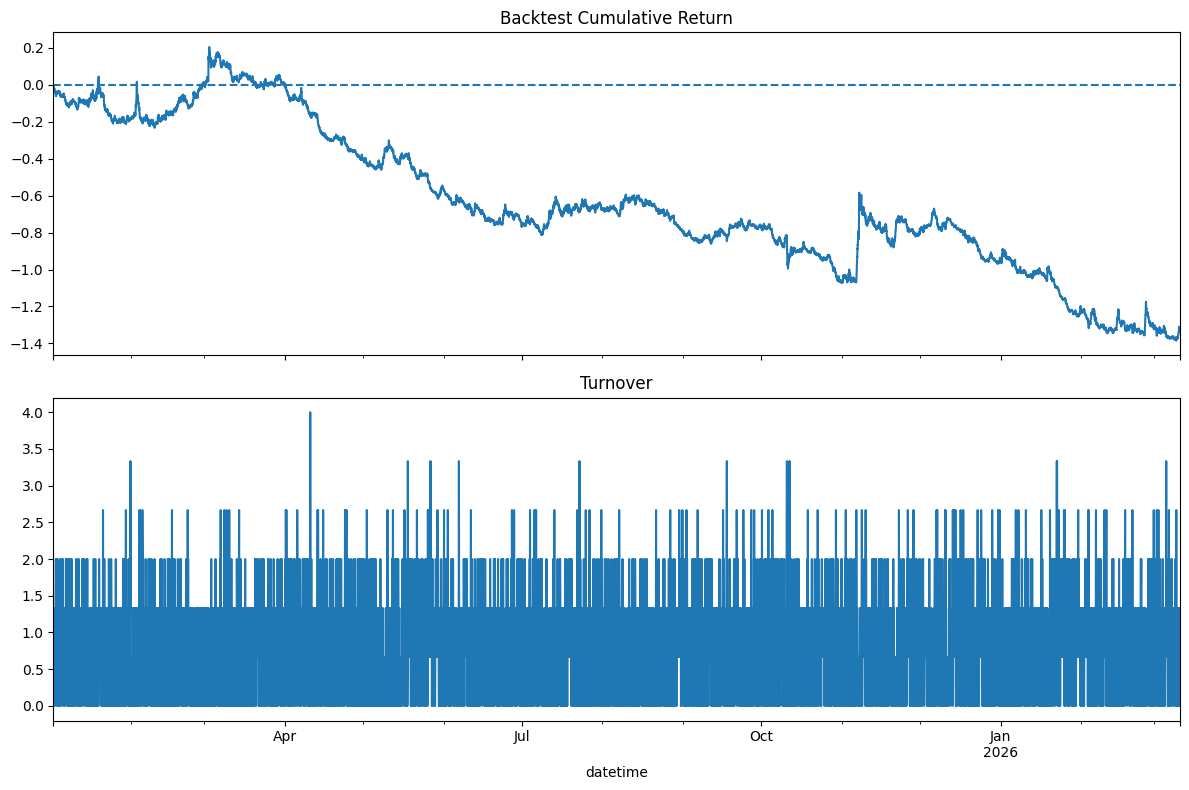

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

bt["cum_returns"].plot(ax=axes[0], title="Backtest Cumulative Return")
axes[0].axhline(0, linestyle="--")

bt["turnover"].plot(ax=axes[1], title="Turnover")

plt.tight_layout()
plt.show()

In [12]:
all_bt_rows = []

for factor_name in factor_names:
    try:
        bt = engine.run_backtest(
            panel_df=panel_df,
            factor_df=factor_df,
            factor_name=factor_name,
            horizon=1,
            method="top_bottom_equal_weight",
            quantile=0.2,
        )

        metrics = summarize_backtest(
            portfolio_returns=bt["portfolio_returns"],
            turnover=bt["turnover"],
            periods_per_year=24 * 365,
        )
        metrics["factor_name"] = factor_name
        all_bt_rows.append(metrics)

    except Exception as e:
        print(f"[WARN] backtest failed for {factor_name}: {e}")

bt_summary_df = pd.DataFrame(all_bt_rows).sort_values("sharpe", ascending=False)
bt_summary_df

[WARN] backtest failed for mom_24h: name 'engine' is not defined
[WARN] backtest failed for rev_6h: name 'engine' is not defined
[WARN] backtest failed for funding_z_24: name 'engine' is not defined
[WARN] backtest failed for oi_chg_24h: name 'engine' is not defined
[WARN] backtest failed for taker_imbalance: name 'engine' is not defined
[WARN] backtest failed for ls_ratio_z_24: name 'engine' is not defined
[WARN] backtest failed for active_community_count_z_24: name 'engine' is not defined
[WARN] backtest failed for volume_ratio_24: name 'engine' is not defined
[WARN] backtest failed for close_to_ma24: name 'engine' is not defined


KeyError: 'sharpe'

In [14]:
factor_df

,datetime,symbol,mom_24h,rev_6h,funding_z_24,oi_chg_24h,taker_imbalance,ls_ratio_z_24,active_community_count_z_24,volume_ratio_24,close_to_ma24
0,2025-01-01,ADAUSDT,NaN,NaN,NaN,NaN,0.224374,NaN,NaN,NaN,NaN
1,2025-01-01,APTUSDT,NaN,NaN,NaN,NaN,0.117690,NaN,NaN,NaN,NaN
2,2025-01-01,ATOMUSDT,NaN,NaN,NaN,NaN,0.014625,NaN,NaN,NaN,NaN
3,2025-01-01,AVAXUSDT,NaN,NaN,NaN,NaN,0.151342,NaN,NaN,NaN,NaN
4,2025-01-01,BCHUSDT,NaN,NaN,NaN,NaN,0.078970,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
197918,2026-03-11,NEARUSDT,0.041129,-0.003888,1.400474,0.0,0.097630,NaN,NaN,0.857015,0.004213
197919,2026-03-11,SOLUSDT,0.005262,0.002553,-0.755954,0.0,-0.023124,NaN,NaN,0.661205,-0.007007
197920,2026-03-11,TRXUSDT,-0.000350,-0.003588,1.232053,0.0,-0.056922,NaN,NaN,0.819330,0.000870
197921,2026-03-11,XLMUSDT,0.045769,0.012929,0.581293,0.0,0.221380,NaN,NaN,0.817695,-0.003087


/home/joyce/projects/cross-asset-quant-lab/cryptoAlpha/src/evaluation/factor_evaluator.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic = merged_df.groupby("datetime").apply(lambda g: _safe_corr(g["factor"], g[label_col]))
/home/joyce/projects/cross-asset-quant-lab/cryptoAlpha/src/evaluation/factor_evaluator.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank_ic = merged_df.groupby("datetime").apply(lamb

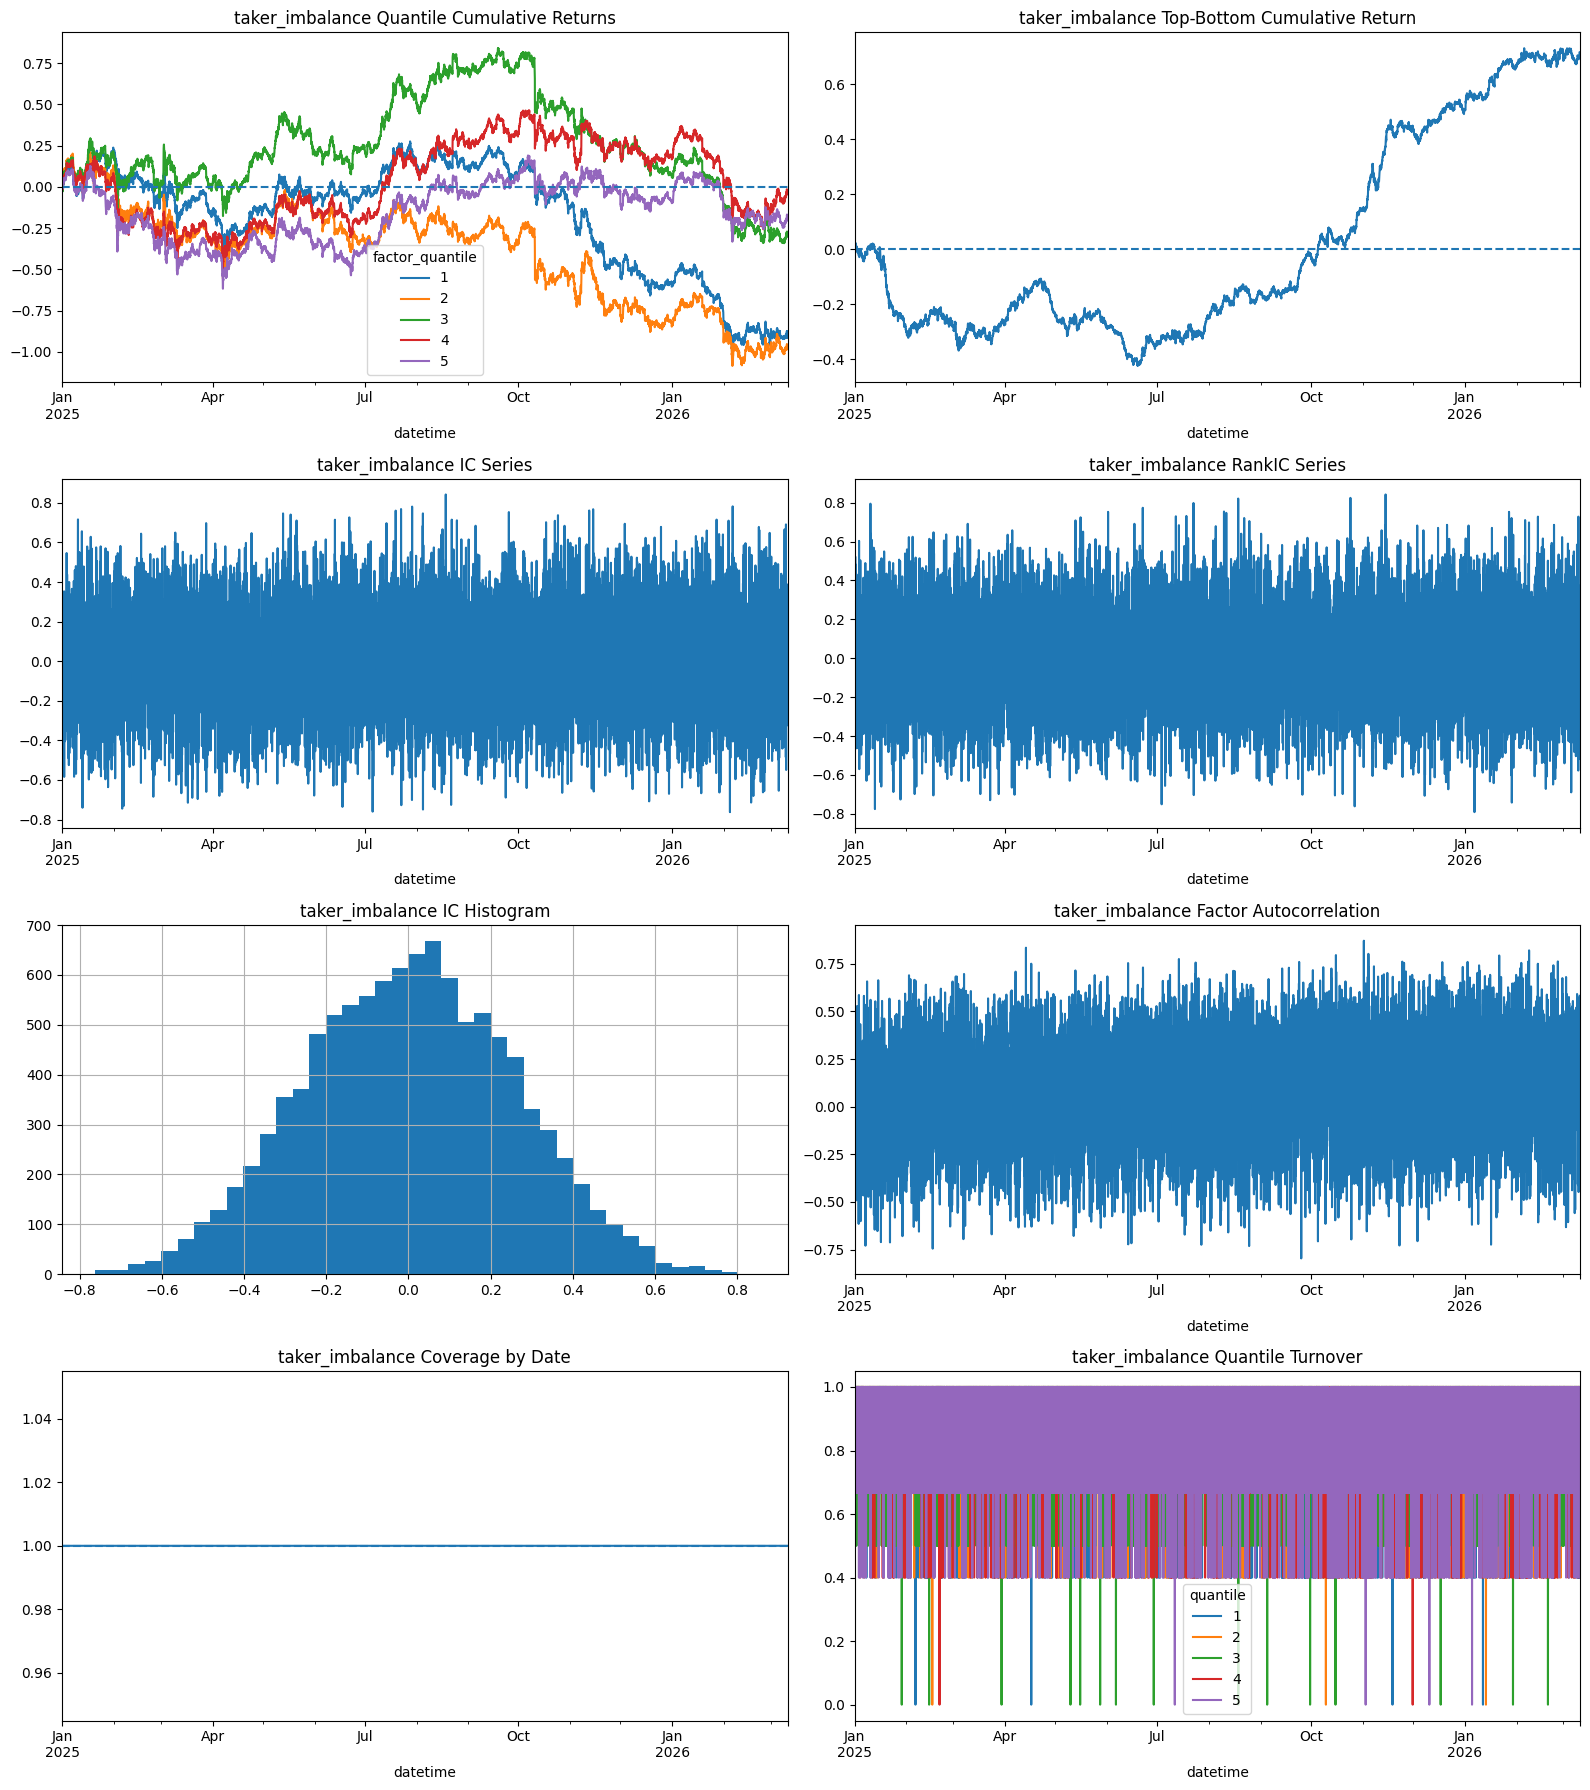

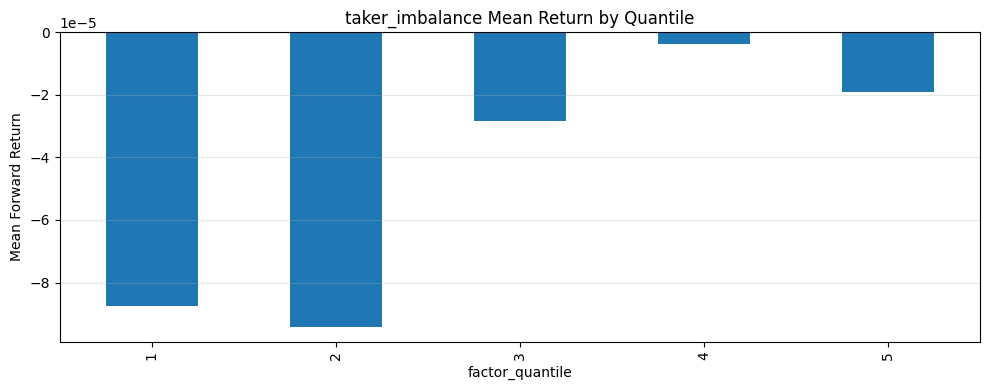

=== taker_imbalance Yearly IC Table ===
   year   ic_mean    ic_std  rank_ic_mean  rank_ic_std     ic_ir  rank_ic_ir
0  2025  0.002504  0.252054      0.001947     0.248671  0.009933    0.007831
1  2026  0.004122  0.262279     -0.000002     0.252789  0.015717   -0.000009


,year,ic_mean,ic_std,rank_ic_mean,rank_ic_std,ic_ir,rank_ic_ir
0,2025,0.002504,0.252054,0.001947,0.248671,0.009933,0.007831
1,2026,0.004122,0.262279,-0.000002,0.252789,0.015717,-0.000009


In [13]:
from src.evaluation.factor_plotter import FactorPlotter

evaluator = FactorEvaluator(price_col="close")
plotter = FactorPlotter()

result = evaluator.evaluate_one_factor(
    panel_df=panel_df,
    factor_df=factor_df,
    factor_name="taker_imbalance",
    horizon=1,
    group_num=5,
)

result["summary"]
plotter.plot_full_report(result, factor_name="taker_imbalance")
plotter.plot_quantile_bar(result, factor_name="taker_imbalance")
plotter.plot_yearly_ic_table(result, factor_name="taker_imbalance")